# Pong DQN — evaluation

Evaluates a trained DQN checkpoint under three conditions, each changing exactly
one thing relative to the deterministic baseline:

| Condition | frameskip | sticky actions | random no-op starts |
|---|---|---|---|
| Baseline (Pong-v4) | 4, fixed | no | no |
| Sticky actions | 4, fixed | 25% | no |
| No-op starts | 4, fixed | no | up to 30 |

In [1]:
import os
import cv2
import time
import random
import torch
import imageio
import ale_py
import numpy as np
import gymnasium as gym
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import deque, namedtuple
from gymnasium.wrappers import AtariPreprocessing
from torch.utils.tensorboard import SummaryWriter
from IPython.display import Image

In [2]:
gym.register_envs(ale_py)
gym.__version__

'1.3.0'

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Baseline: fully deterministic

Fixed frameskip, no sticky actions, no random starts, and a greedy policy
(eps = 0.0) make both the environment and the policy deterministic. Every
episode is therefore the *same trajectory*. The 20 episodes below are one
result repeated 20 times, not 20 independent samples — effective n = 1.

The no-op-start section further down is the one that gives genuine n = 20.

In [4]:
# Baseline eval env: deterministic frameskip 4, no sticky actions (v4 default is 0%)
env = gym.make("Pong-v4", render_mode="rgb_array", frameskip=4)

A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[Powered by Stella]


In [5]:
def frame_preprocess(frame,width=84, height=84):
    
    frame = cv2.resize(frame[35:190],(width,height))
    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    return frame

In [6]:
def get_states(curr_frame, prev_state=None):
    curr_frame =  frame_preprocess(curr_frame)
    if prev_state is None:
        s = np.dstack([curr_frame, curr_frame, curr_frame, curr_frame])
    else:
        a,b,c,d = np.dsplit(prev_state, 4)
        s = np.dstack([curr_frame,a,b,c])
    return s

In [7]:
class QNetwork(nn.Module):
    
    def __init__(self, input_channels, action_size):
        super().__init__()
        self.input_channels = input_channels
        self.action_size = action_size

        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1) #7x7
        self.linear1 = nn.Linear(7*7*64, 512)
        self.linear2 = nn.Linear(512,action_size)

    def forward(self,x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.linear1(x.reshape(x.shape[0], -1)))
        x = self.linear2(x)

        return x

In [9]:
def epsilon_greedy_action(model: QNetwork, state: torch.Tensor, epsilon: float, env):
    """Epsilon-greedy action. The forward pass only runs when we actually act greedily."""
    if random.random() < epsilon:
        return int(np.random.choice(np.arange(env.action_space.n)))

    with torch.no_grad():
        q_values = model(state)
    return int(torch.argmax(q_values, dim=1).item())

In [10]:
model = QNetwork(4, env.action_space.n)
model.load_state_dict(torch.load("./checkpoint_local_pong_frame_skips.pth"))
model.to(device)
model.eval()  

QNetwork(
  (conv1): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
  (conv2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (linear1): Linear(in_features=3136, out_features=512, bias=True)
  (linear2): Linear(in_features=512, out_features=6, bias=True)
)

In [11]:
def get_scores(env, no_episodes, eps, seed=None, verbose=True):
    """Run `no_episodes` greedy episodes and return (scores, seeds).

    Pass `seed` to make the run reproducible: episode i is reset with seed+i,
    and the seeds are returned alongside the scores so results can be replayed.
    """
    all_scores, used_seeds = [], []

    for epi_no in range(no_episodes):
        epi_seed = None if seed is None else seed + epi_no
        used_seeds.append(epi_seed)

        epi_return = 0.0
        obs, info = env.reset() if epi_seed is None else env.reset(seed=epi_seed)
        state = get_states(obs, None)

        while True:
            state_tensor = torch.tensor(state).permute(2, 0, 1).float().to(device).unsqueeze(0)
            action = epsilon_greedy_action(model, state_tensor, eps, env)
            next_obs, reward, done, truncated, info = env.step(action)
            epi_return += reward
            if done or truncated:
                break
            state = get_states(next_obs, state)

        all_scores.append(epi_return)
        if verbose:
            print(f"Episode: {epi_no}  seed: {epi_seed}  Score: {epi_return}")

    return all_scores, used_seeds


def summarize(name, scores):
    scores = np.asarray(scores, dtype=np.float64)
    print(f"{name}: mean {scores.mean():.2f}  std {scores.std(ddof=1):.2f}  "
          f"min {scores.min():.0f}  max {scores.max():.0f}  n {len(scores)}")
    return scores

In [12]:
scores_pong, seeds_pong = get_scores(env, no_episodes=20, eps=0.0, seed=0)

Episode: 0  seed: 0  Score: 21.0
Episode: 1  seed: 1  Score: 21.0
Episode: 2  seed: 2  Score: 21.0
Episode: 3  seed: 3  Score: 21.0
Episode: 4  seed: 4  Score: 21.0
Episode: 5  seed: 5  Score: 21.0
Episode: 6  seed: 6  Score: 21.0
Episode: 7  seed: 7  Score: 21.0
Episode: 8  seed: 8  Score: 21.0
Episode: 9  seed: 9  Score: 21.0
Episode: 10  seed: 10  Score: 21.0
Episode: 11  seed: 11  Score: 21.0
Episode: 12  seed: 12  Score: 21.0
Episode: 13  seed: 13  Score: 21.0
Episode: 14  seed: 14  Score: 21.0
Episode: 15  seed: 15  Score: 21.0
Episode: 16  seed: 16  Score: 21.0
Episode: 17  seed: 17  Score: 21.0
Episode: 18  seed: 18  Score: 21.0
Episode: 19  seed: 19  Score: 21.0


In [13]:
_ = summarize("Baseline (deterministic)", scores_pong)
print("Note: env and policy are both deterministic here, so effective n = 1.")

Baseline (deterministic): mean 21.00  std 0.00  min 21  max 21  n 20
Note: env and policy are both deterministic here, so effective n = 1.


## Sticky actions

`repeat_action_probability=0.25` means a quarter of the time the previous action
is repeated instead of the one the agent chose. This is the standard modern
randomisation for Atari, and the agent was not trained under it.

In [14]:
env_sticky = gym.make("ALE/Pong-v5", frameskip=4, repeat_action_probability=0.25)

In [15]:
scores_pong_repeat_actions, seeds_sticky = get_scores(
    env_sticky, no_episodes=20, eps=0.0, seed=0)

Episode: 0  seed: 0  Score: 2.0
Episode: 1  seed: 1  Score: 3.0
Episode: 2  seed: 2  Score: 11.0
Episode: 3  seed: 3  Score: 4.0
Episode: 4  seed: 4  Score: 14.0
Episode: 5  seed: 5  Score: 10.0
Episode: 6  seed: 6  Score: 7.0
Episode: 7  seed: 7  Score: 9.0
Episode: 8  seed: 8  Score: 5.0
Episode: 9  seed: 9  Score: 10.0
Episode: 10  seed: 10  Score: 7.0
Episode: 11  seed: 11  Score: 13.0
Episode: 12  seed: 12  Score: 14.0
Episode: 13  seed: 13  Score: 10.0
Episode: 14  seed: 14  Score: 11.0
Episode: 15  seed: 15  Score: 10.0
Episode: 16  seed: 16  Score: 11.0
Episode: 17  seed: 17  Score: 4.0
Episode: 18  seed: 18  Score: 10.0
Episode: 19  seed: 19  Score: 12.0


In [16]:
_ = summarize("Sticky actions (p=0.25)", scores_pong_repeat_actions)

Sticky actions (p=0.25): mean 8.85  std 3.63  min 2  max 14  n 20


## Random no-op starts

Up to 30 no-op actions on reset shift the game's starting phase, so each episode
is a genuinely different trajectory. This is the test that carries real n = 20.

`AtariPreprocessing` is used **only** for its `noop_max` behaviour here:

- `frame_skip=1` in the wrapper, because the underlying env already skips 4.
- `screen_size=(160, 210)` is an intentional identity resize — Pong's native
  frame is 210 high by 160 wide, and cv2 takes (width, height). This keeps the
  raw frame intact so `frame_preprocess` below still does the cropping and
  resizing, exactly as during training.
- `grayscale_obs=False` for the same reason.

In [17]:
env_noop = gym.make("ALE/Pong-v5", frameskip=4, repeat_action_probability=0.0)
env_noop = AtariPreprocessing(
    env_noop,
    noop_max=30,
    frame_skip=1,              # underlying env already skips 4
    screen_size=(160, 210),    # identity resize: keeps the native 210x160 frame
    grayscale_obs=False,       # our own frame_preprocess handles grayscale
)

In [18]:
scores_pong_noops, seeds_noop = get_scores(env_noop, no_episodes=20, eps=0.0, seed=0)

Episode: 0  seed: 0  Score: 21.0
Episode: 1  seed: 1  Score: 21.0
Episode: 2  seed: 2  Score: 21.0
Episode: 3  seed: 3  Score: 21.0
Episode: 4  seed: 4  Score: 21.0
Episode: 5  seed: 5  Score: 21.0
Episode: 6  seed: 6  Score: 21.0
Episode: 7  seed: 7  Score: 21.0
Episode: 8  seed: 8  Score: 21.0
Episode: 9  seed: 9  Score: 21.0
Episode: 10  seed: 10  Score: 21.0
Episode: 11  seed: 11  Score: 21.0
Episode: 12  seed: 12  Score: 21.0
Episode: 13  seed: 13  Score: 21.0
Episode: 14  seed: 14  Score: 21.0
Episode: 15  seed: 15  Score: 21.0
Episode: 16  seed: 16  Score: 21.0
Episode: 17  seed: 17  Score: 21.0
Episode: 18  seed: 18  Score: 21.0
Episode: 19  seed: 19  Score: 21.0


In [19]:
_ = summarize("Random no-op starts", scores_pong_noops)
print("Seeds:", seeds_noop)

Random no-op starts: mean 21.00  std 0.00  min 21  max 21  n 20
Seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


## Results

In [20]:
import pandas as pd

results = pd.DataFrame({
    "condition": ["Baseline (deterministic)", "Sticky actions (p=0.25)", "No-op starts (<=30)"],
    "mean":  [np.mean(scores_pong), np.mean(scores_pong_repeat_actions), np.mean(scores_pong_noops)],
    "std":   [np.std(scores_pong, ddof=1), np.std(scores_pong_repeat_actions, ddof=1), np.std(scores_pong_noops, ddof=1)],
    "min":   [np.min(scores_pong), np.min(scores_pong_repeat_actions), np.min(scores_pong_noops)],
    "max":   [np.max(scores_pong), np.max(scores_pong_repeat_actions), np.max(scores_pong_noops)],
    "effective_n": [1, 20, 20],
})
results.round(2)

,condition,mean,std,min,max,effective_n
0,Baseline (deterministic),21.00,0.00,21.0,21.0,1
1,Sticky actions (p=0.25),8.85,3.63,2.0,14.0,20
2,No-op starts (<=30),21.00,0.00,21.0,21.0,20


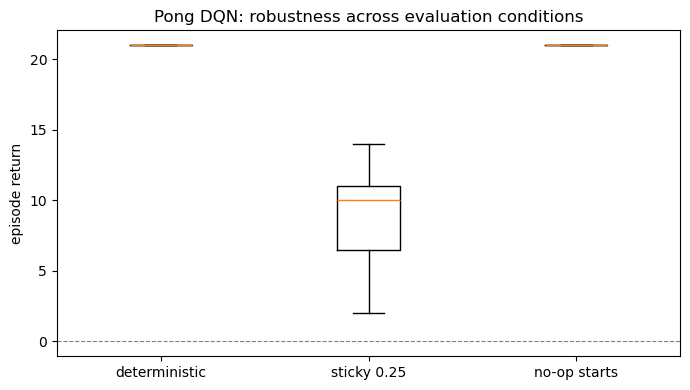

In [24]:
plt.figure(figsize=(7, 4))
plt.boxplot(
    [scores_pong, scores_pong_repeat_actions, scores_pong_noops],
    tick_labels=["deterministic", "sticky 0.25", "no-op starts"],
)
plt.axhline(0, color="grey", lw=0.8, ls="--")
plt.ylabel("episode return")
plt.title("Pong DQN: robustness across evaluation conditions")
plt.tight_layout()
plt.show()

## Recording

Each stored observation covers 4 emulator frames, so real-time playback is
15 fps, not 30. An mp4 is written as well — a full episode of 210x160 RGB
frames makes a large GIF.

In [27]:
record_env = gym.make("ALE/Pong-v5", frameskip=4, repeat_action_probability=0.0,
                      render_mode="rgb_array")
record_env = AtariPreprocessing(record_env, noop_max=30, frame_skip=1,
                                screen_size=(160, 210), grayscale_obs=False)

RECORD_SEED = 0
all_obs = []

obs, info = record_env.reset(seed=RECORD_SEED)
state = get_states(obs, None)
episode_return = 0.0

while True:
    state_tensor = torch.tensor(state).permute(2, 0, 1).float().to(device).unsqueeze(0)
    action = epsilon_greedy_action(model, state_tensor, 0.0, record_env)
    next_obs, reward, done, truncated, info = record_env.step(action)
    all_obs.append(next_obs)
    episode_return += reward
    if done or truncated:
        break
    state = get_states(next_obs, state)

print(f"Recorded {len(all_obs)} frames, episode return {episode_return}")

FPS = 15  # frameskip 4 at 60 Hz -> 15 agent steps per second of game time
imageio.mimsave("pong_trained.mp4", all_obs, fps=FPS)
imageio.mimsave("pong_trained.gif", all_obs[::2], fps=FPS // 2, loop=0)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (160, 210) to (160, 224) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Recorded 1579 frames, episode return 21.0


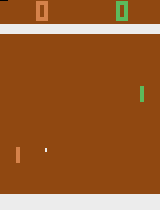

In [28]:
Image(filename="pong_trained.gif")